# 02 - DataFrames & SparkSQL Analysis
This notebook covers analytical queries, window functions, and visualizations using SparkSQL.

In [ ]:
# --- SELF-CONTAINED SETUP AND DATA INGESTION ---
# This cell handles imports, SparkSession initialization, and data preparation
# so this notebook can run independently of previous notebooks.

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, sum, avg, when, isnan, round, desc, asc, year, month, to_date, countDistinct, date_sub, abs, max, datediff, lit

# Initialize Spark Session
spark = SparkSession.builder \
    .appName("BigDataMarketing_Submodule") \
    .getOrCreate()

# Find dataset
file_path = "../data/online_retail_II.xlsx"
if not os.path.exists(file_path):
    file_path = "online_retail_II.xlsx"
if not os.path.exists(file_path):
    file_path = "data/online_retail_II.xlsx"
if not os.path.exists(file_path):
    file_path = "/teamspace/studios/this_studio/Datasetes/online_retail_II.xlsx"

print(f"Loading dataset from: {file_path}")

# Ingest raw data
pandas_df_1 = pd.read_excel(file_path, sheet_name="Year 2009-2010", engine="openpyxl")
pandas_df_2 = pd.read_excel(file_path, sheet_name="Year 2010-2011", engine="openpyxl")
pandas_df = pd.concat([pandas_df_1, pandas_df_2], ignore_index=True)

# Clean and prepare DataFrame
retail_df = spark.createDataFrame(pandas_df)
retail_df = retail_df.withColumnRenamed("Customer ID", "CustomerID")
retail_df = retail_df.filter(col("CustomerID").isNotNull() & ~isnan(col("CustomerID")))
retail_df = retail_df.withColumn("CustomerID", col("CustomerID").cast("integer").cast("string"))
retail_df = retail_df.distinct()

# Remove cancellations and invalid records for core sales analysis
retail_df = retail_df.filter(
    (~col("Invoice").startswith("C")) &
    (col("Quantity") > 0) &
    (col("Price") > 0)
).cache()

print(f"Data preparation complete. Clean rows: {retail_df.count():,}")


### DATAFRAMES & SPARKSQL

In [37]:
# Register our clean DataFrame as a temporary SQL view. This allows us to query it using pure SQL

retail_df.createOrReplaceTempView("retail")

print("Table registered successfully!")

Table registered successfully!


In [38]:
# SPARKSQL — Revenue by Country
# Which markets generate the most revenue for our client?

country_revenue = spark.sql("""
    SELECT 
        Country,
        COUNT(DISTINCT Invoice) AS total_orders,
        COUNT(DISTINCT CustomerID) AS total_customers,
        ROUND(SUM(Quantity * Price), 2) AS total_revenue
    FROM retail
    GROUP BY Country
    ORDER BY total_revenue DESC
    LIMIT 10
""")

country_revenue.show(truncate=False)
print("Top 10 Countries genereting the most revenue")

+--------------+------------+---------------+-------------+
|Country       |total_orders|total_customers|total_revenue|
+--------------+------------+---------------+-------------+
|United Kingdom|33541       |5350           |1.438923492E7|
|EIRE          |567         |5              |616570.54    |
|Netherlands   |228         |22             |554038.09    |
|Germany       |789         |107            |425019.71    |
|France        |614         |95             |348768.96    |
|Australia     |95          |15             |169283.46    |
|Spain         |154         |41             |108332.49    |
|Switzerland   |90          |22             |100061.94    |
|Sweden        |104         |19             |91515.82     |
|Denmark       |43          |12             |68580.69     |
+--------------+------------+---------------+-------------+

Top 10 Countries genereting the most revenue


In [39]:
# DATAFRAME API — Same query as above but using DataFrame syntax

country_revenue_df = retail_df.groupBy("Country") \
    .agg(
        countDistinct("Invoice").alias("total_orders"),
        countDistinct("CustomerID").alias("total_customers"),
        round(sum(col("Quantity") * col("Price")), 2).alias("total_revenue")
    ) \
    .orderBy(col("total_revenue").desc()) \
    .limit(10)

country_revenue_df.show(truncate=False)

+--------------+------------+---------------+-------------+
|Country       |total_orders|total_customers|total_revenue|
+--------------+------------+---------------+-------------+
|United Kingdom|33541       |5350           |1.438923492E7|
|EIRE          |567         |5              |616570.54    |
|Netherlands   |228         |22             |554038.09    |
|Germany       |789         |107            |425019.71    |
|France        |614         |95             |348768.96    |
|Australia     |95          |15             |169283.46    |
|Spain         |154         |41             |108332.49    |
|Switzerland   |90          |22             |100061.94    |
|Sweden        |104         |19             |91515.82     |
|Denmark       |43          |12             |68580.69     |
+--------------+------------+---------------+-------------+



#### Q1a - Top 10 products by revenue

In [40]:
# SPARKSQL — Top 10 best selling products by revenue

top_products = spark.sql("""
    SELECT 
        StockCode,
        Description,
        SUM(Quantity) AS total_units_sold,
        ROUND(SUM(Quantity * Price), 2) AS total_revenue
    FROM retail
    GROUP BY StockCode, Description
    ORDER BY total_revenue DESC
    LIMIT 10
""")

top_products.show(truncate=False)

+---------+----------------------------------+----------------+-------------+
|StockCode|Description                       |total_units_sold|total_revenue|
+---------+----------------------------------+----------------+-------------+
|22423    |REGENCY CAKESTAND 3 TIER          |24124           |277656.25    |
|85123A   |WHITE HANGING HEART T-LIGHT HOLDER|91757           |247048.01    |
|23843    |PAPER CRAFT , LITTLE BIRDIE       |80995           |168469.6     |
|M        |Manual                            |9384            |151777.67    |
|85099B   |JUMBO BAG RED RETROSPOT           |74224           |134307.44    |
|POST     |POSTAGE                           |5235            |124648.04    |
|84879    |ASSORTED COLOUR BIRD ORNAMENT     |78234           |124351.86    |
|47566    |PARTY BUNTING                     |23460           |103283.38    |
|23166    |MEDIUM CERAMIC TOP STORAGE JAR    |77916           |81416.73     |
|22086    |PAPER CHAIN KIT 50'S CHRISTMAS    |28380           |7

In [41]:
from pyspark.ml.fpm import FPGrowth
from pyspark.sql.functions import collect_set, size

# Consolidate invoices into single transactional rows (baskets)
# Filter for baskets with more than 1 item to ensure cross-selling patterns exist
basket_df = retail_df.groupBy("Invoice") \
    .agg(collect_set("Description").alias("Baskets")) \
    .filter(size(col("Baskets")) > 1)

# 2. Initialize and fit the FP-Growth model
# minSupport=0.01 means an itemset must appear in at least 1% of all transactions
# minConfidence=0.40 means the predictive rule must be accurate at least 40% of the time
fp_growth = FPGrowth(itemsCol="Baskets", minSupport=0.01, minConfidence=0.40)
fpm_model = fp_growth.fit(basket_df)

print("=== POPULAR PRODUCT BUNDLES (FREQUENT ITEMSETS) ===")
# Shows groupings that frequently show up together
fpm_model.freqItemsets \
    .filter(size(col("items")) > 1) \
    .orderBy(desc("freq")) \
    .show(15, truncate=False)

print("=== STRONG ASSOCIATION RULES FOR CROSS-SELLING ===")
# Shows 'if they buy [antecedent], they are highly likely to buy [consequent]'
fpm_model.associationRules \
    .orderBy(desc("confidence"), desc("lift")) \
    .show(15, truncate=False)

=== POPULAR PRODUCT BUNDLES (FREQUENT ITEMSETS) ===


+----------------------------------------------------------------------+----+
|items                                                                 |freq|
+----------------------------------------------------------------------+----+
|[RED HANGING HEART T-LIGHT HOLDER, WHITE HANGING HEART T-LIGHT HOLDER]|1153|
|[WOODEN PICTURE FRAME WHITE FINISH, WOODEN FRAME ANTIQUE WHITE ]      |993 |
|[HEART OF WICKER LARGE, HEART OF WICKER SMALL]                        |869 |
|[SWEETHEART CERAMIC TRINKET BOX, STRAWBERRY CERAMIC TRINKET BOX]      |817 |
|[LOVE BUILDING BLOCK WORD, HOME BUILDING BLOCK WORD]                  |786 |
|[LUNCH BAG SPACEBOY DESIGN , LUNCH BAG  BLACK SKULL.]                 |774 |
|[GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER ]   |743 |
|[LUNCH BAG CARS BLUE, LUNCH BAG  BLACK SKULL.]                        |741 |
|[PACK OF 60 PINK PAISLEY CAKE CASES, 60 TEATIME FAIRY CAKE CASES]     |736 |
|[JUMBO STORAGE BAG SUKI, JUMBO BAG RED RETROSPOT]              

+------------------------------------------------------------------+------------------------------------+------------------+------------------+--------------------+
|antecedent                                                        |consequent                          |confidence        |lift              |support             |
+------------------------------------------------------------------+------------------------------------+------------------+------------------+--------------------+
|[POPPY'S PLAYHOUSE LIVINGROOM , POPPY'S PLAYHOUSE BEDROOM ]       |[POPPY'S PLAYHOUSE KITCHEN]         |0.9267015706806283|50.99416094376827 |0.010443402070979733|
|[PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER ]|[GREEN REGENCY TEACUP AND SAUCER]   |0.8927973199329984|32.47119179588932 |0.015724105378057057|
|[PINK REGENCY TEACUP AND SAUCER, REGENCY CAKESTAND 3 TIER]        |[GREEN REGENCY TEACUP AND SAUCER]   |0.8873239436619719|32.27212416127667 |0.011151429330029206|
|[POPPY'S 

#### Q3b - Seasonality identification

In [42]:
# Revenue trend by month
# Which months are most profitable?

monthly_revenue = spark.sql("""
    SELECT 
        YEAR(InvoiceDate) AS year,
        MONTH(InvoiceDate) AS month,
        ROUND(SUM(Quantity * Price), 2) AS total_revenue,
        COUNT(DISTINCT CustomerID) AS active_customers
    FROM retail
    GROUP BY YEAR(InvoiceDate), 
        MONTH(InvoiceDate)
    ORDER BY year ASC, month ASC
""")

monthly_revenue.show(24, truncate=False)

+----+-----+-------------+----------------+
|year|month|total_revenue|active_customers|
+----+-----+-------------+----------------+
|2009|12   |683504.01    |955             |
|2010|1    |555802.67    |720             |
|2010|2    |504558.96    |772             |
|2010|3    |696978.47    |1057            |
|2010|4    |591982.0     |942             |
|2010|5    |597833.38    |966             |
|2010|6    |636371.13    |1041            |
|2010|7    |589736.17    |928             |
|2010|8    |602224.6     |911             |
|2010|9    |829013.95    |1145            |
|2010|10   |1033112.01   |1497            |
|2010|11   |1166460.02   |1607            |
|2010|12   |570422.73    |885             |
|2011|1    |568101.31    |741             |
|2011|2    |446084.92    |758             |
|2011|3    |594081.76    |974             |
|2011|4    |468374.33    |856             |
|2011|5    |677355.15    |1056            |
|2011|6    |660046.05    |991             |
|2011|7    |598962.9     |949   

In [43]:
# Average Order Value by country — SparkSQL
aov_by_country = spark.sql("""
    SELECT 
        Country,
        COUNT(DISTINCT Invoice)                              AS order_count,
        ROUND(SUM(Quantity * Price), 2)                     AS total_revenue,
        ROUND(SUM(Quantity * Price) / COUNT(DISTINCT Invoice), 2) AS avg_order_value
    FROM retail
    GROUP BY Country
    HAVING order_count >= 10
    ORDER BY avg_order_value DESC
""")

print("=== Average Order Value by Country ===")
aov_by_country.show(20, truncate=False)

=== Average Order Value by Country ===


+--------------------+-----------+-------------+---------------+
|Country             |order_count|total_revenue|avg_order_value|
+--------------------+-----------+-------------+---------------+
|Netherlands         |228        |554038.09    |2429.99        |
|Singapore           |11         |25317.06     |2301.55        |
|Australia           |95         |169283.46    |1781.93        |
|Denmark             |43         |68580.69     |1594.9         |
|Japan               |33         |43023.91     |1303.75        |
|Norway              |45         |56322.5      |1251.61        |
|Switzerland         |90         |100061.94    |1111.8         |
|EIRE                |567        |616570.54    |1087.43        |
|Greece              |18         |19096.19     |1060.9         |
|Sweden              |104        |91515.82     |879.96         |
|United Arab Emirates|11         |9202.69      |836.61         |
|Channel Islands     |55         |44623.33     |811.33         |
|Spain               |154

#### Convert Spark result to Pandas just for plotting
### VISUALISATIONS

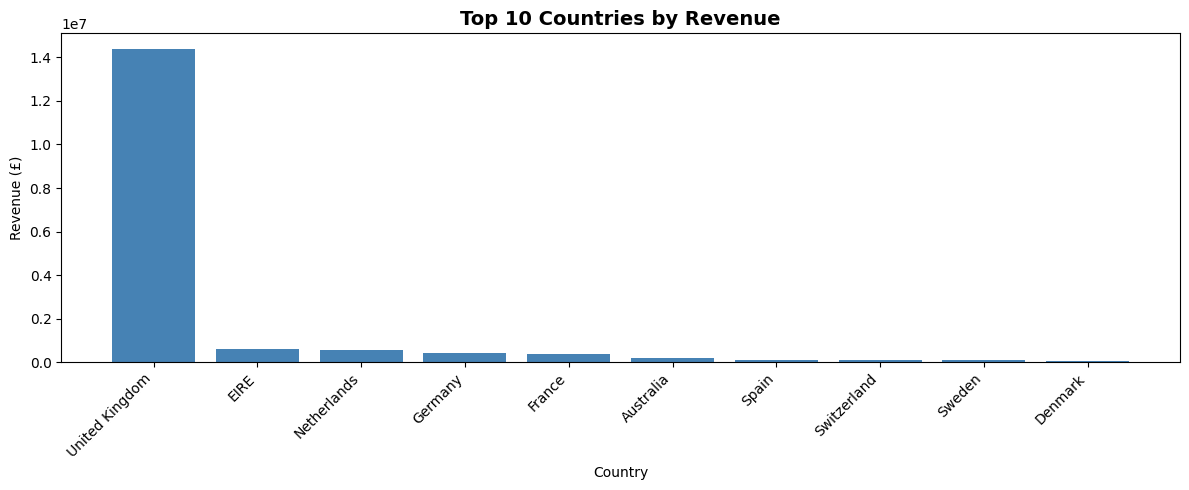

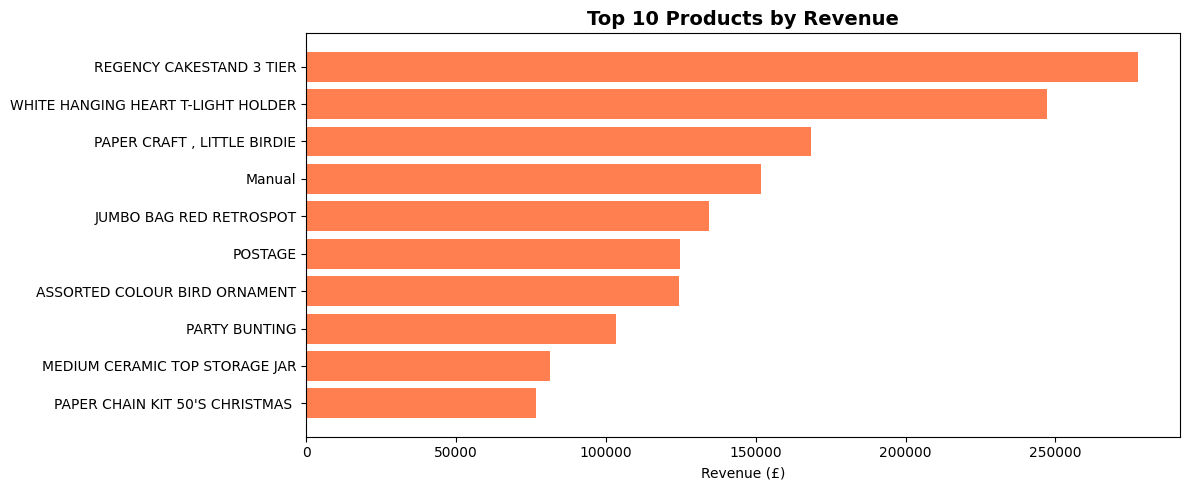

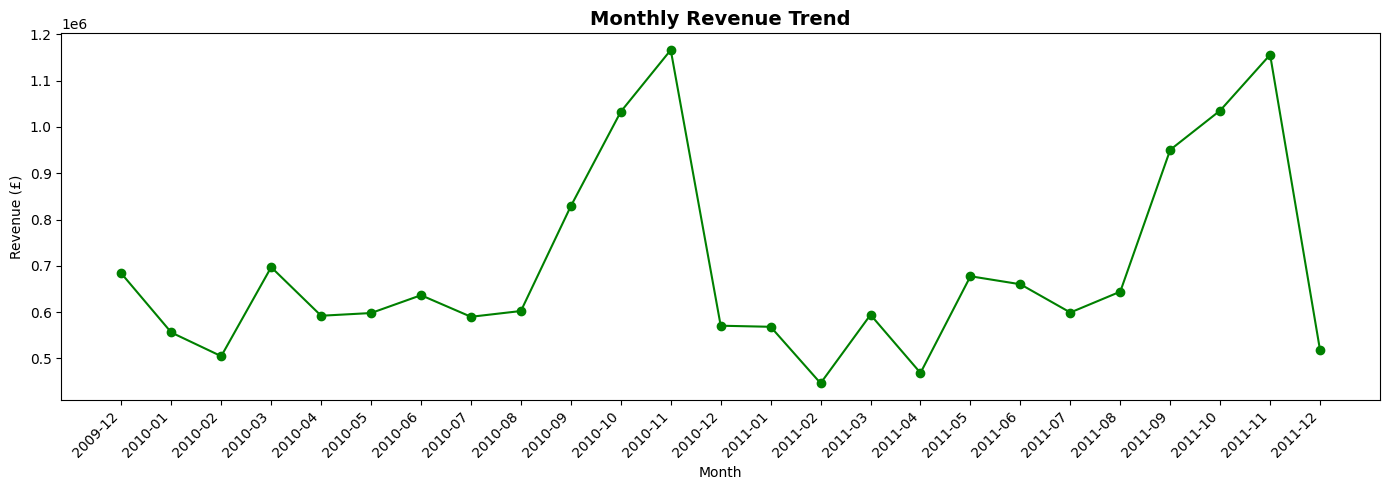

In [44]:
#DISCLAIMER: no data sample the data here because the data was already treated to not exceed 24 rows, LIMIT 10 and LIMIT 10, 
# respectively, for country_revenue, top_products and monthly_revenue

#Chart 1: Revenue by Country 
country_pd = country_revenue.toPandas()

plt.figure(figsize=(12, 5))
plt.bar(country_pd["Country"], country_pd["total_revenue"], color="steelblue")
plt.title("Top 10 Countries by Revenue", fontsize=14, fontweight="bold")
plt.xlabel("Country")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Chart 2: Top 10 Products
products_pd = top_products.toPandas()

plt.figure(figsize=(12, 5))
plt.barh(products_pd["Description"], products_pd["total_revenue"], color="coral")
plt.title("Top 10 Products by Revenue", fontsize=14, fontweight="bold")
plt.xlabel("Revenue (£)")
plt.gca().invert_yaxis()  # highest at top
plt.tight_layout()
plt.show()

# Chart 3: Monthly Revenue Trend
monthly_pd = monthly_revenue.toPandas()
monthly_pd["period"] = monthly_pd["year"].astype(str) + "-" + monthly_pd["month"].astype(str).str.zfill(2)

plt.figure(figsize=(14, 5))
plt.plot(monthly_pd["period"], monthly_pd["total_revenue"], marker="o", color="green")
plt.title("Monthly Revenue Trend", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [45]:
from pyspark.sql.functions import date_format, lag, round
from pyspark.sql.window import Window

# 1. Construct aggregate monthly revenue footprint for every individual product
product_monthly_revenue = retail_df.withColumn("YearMonth", date_format(col("InvoiceDate"), "yyyy-MM")) \
    .withColumn("LineTotal", col("Quantity") * col("Price")) \
    .groupBy("StockCode", "Description", "YearMonth") \
    .agg(sum("LineTotal").alias("MonthlyRevenue"))

# 2. Define a partition window isolated by product, ordered sequentially by timeline
product_window = Window.partitionBy("StockCode", "Description").orderBy("YearMonth")

# 3. Use lag() to capture trailing performance and compute Month-over-Month (MoM) growth metrics
growth_trends_df = product_monthly_revenue \
    .withColumn("PreviousMonthRevenue", lag("MonthlyRevenue", 1).over(product_window)) \
    .withColumn("MoM_Growth_Value", col("MonthlyRevenue") - col("PreviousMonthRevenue")) \
    .withColumn(
        "MoM_Growth_Percentage", 
        round(((col("MonthlyRevenue") - col("PreviousMonthRevenue")) / col("PreviousMonthRevenue")) * 100, 2)
    )

print("=== GENERAL MOVEMENT OF HIGH-REVENUE TRACTION ITEMS ===")
# Review structural product trajectories by sorting chronologically
growth_trends_df.filter(col("PreviousMonthRevenue").isNotNull()) \
    .orderBy("StockCode", "YearMonth") \
    .select("StockCode", "Description", "YearMonth", "MonthlyRevenue", "MoM_Growth_Value", "MoM_Growth_Percentage") \
    .show(20, truncate=False)

print("=== TOP GROWTH SURGES SPARKING RECENTLY ===")
# Identify trending anomalies or seasonal breakout items by filtering for high volume and high growth %
growth_trends_df.filter((col("MonthlyRevenue") > 1000) & (col("MoM_Growth_Percentage") > 0)) \
    .orderBy(desc("MoM_Growth_Percentage")) \
    .show(15, truncate=False)

=== GENERAL MOVEMENT OF HIGH-REVENUE TRACTION ITEMS ===


+---------+---------------------------+---------+------------------+-------------------+---------------------+
|StockCode|Description                |YearMonth|MonthlyRevenue    |MoM_Growth_Value   |MoM_Growth_Percentage|
+---------+---------------------------+---------+------------------+-------------------+---------------------+
|10002    |INFLATABLE POLITICAL GLOBE |2010-01  |245.64999999999998|65.44999999999999  |36.32                |
|10002    |INFLATABLE POLITICAL GLOBE |2010-02  |216.75            |-28.899999999999977|-11.76               |
|10002    |INFLATABLE POLITICAL GLOBE |2010-03  |479.80999999999995|263.05999999999995 |121.37               |
|10002    |INFLATABLE POLITICAL GLOBE |2010-04  |838.7500000000001 |358.94000000000017 |74.81                |
|10002    |INFLATABLE POLITICAL GLOBE |2010-05  |1064.53           |225.77999999999986 |26.92                |
|10002    |INFLATABLE POLITICAL GLOBE |2010-06  |372.58            |-691.95            |-65.0                |
|

+---------+---------------------------------+---------+------------------+--------------------+------------------+---------------------+
|StockCode|Description                      |YearMonth|MonthlyRevenue    |PreviousMonthRevenue|MoM_Growth_Value  |MoM_Growth_Percentage|
+---------+---------------------------------+---------+------------------+--------------------+------------------+---------------------+
|21181    |PLEASE ONE PERSON METAL SIGN     |2011-09  |4989.720000000001 |2.1                 |4987.620000000001 |237505.71            |
|22469    |HEART OF WICKER SMALL            |2011-05  |3312.64           |3.3                 |3309.3399999999997|100283.03            |
|21915    |RED  HARMONICA IN BOX            |2010-03  |1137.9            |1.25                |1136.65           |90932.0              |
|15036    |ASSORTED COLOURS SILK FAN        |2010-10  |1920.0            |2.25                |1917.75           |85233.33             |
|22961    |JAM MAKING SET PRINTED        

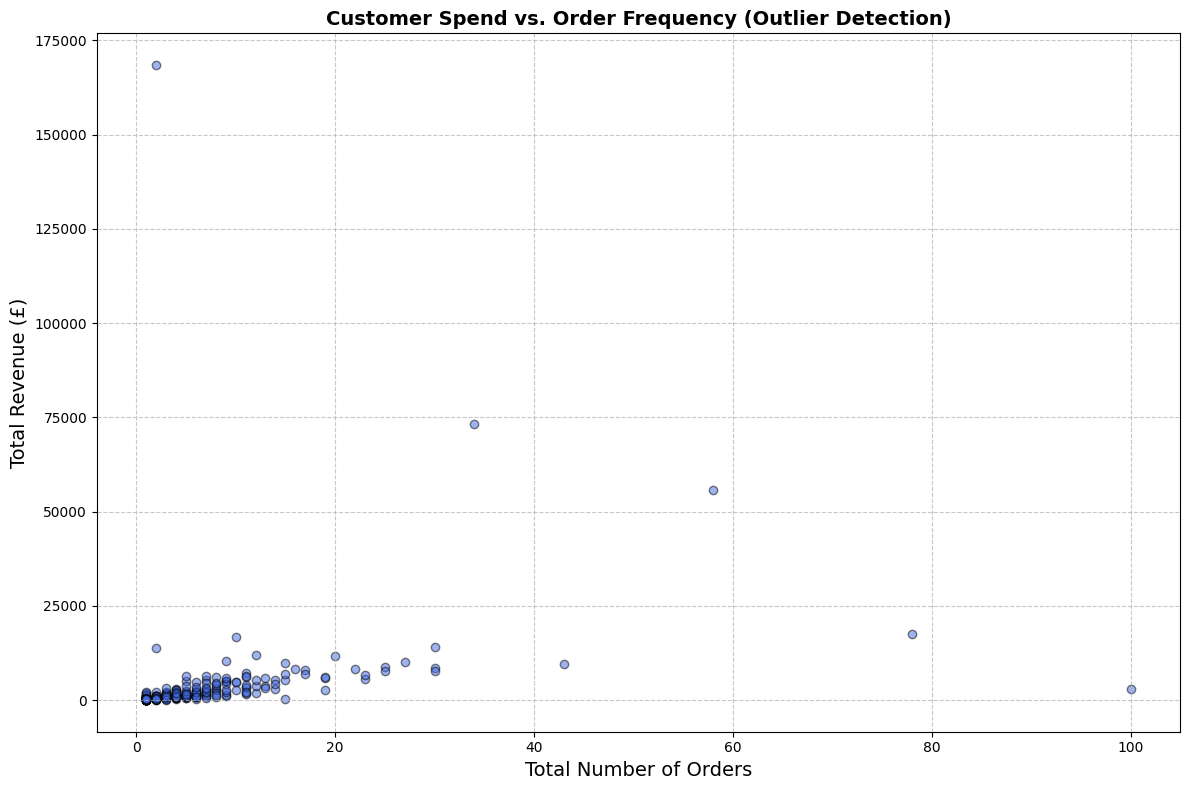

In [46]:
# Chart 4: Customer Spend vs. Order Frequency
customer_scatter_df = retail_df.groupBy("CustomerID").agg(
    sum(col("Quantity") * col("Price")).alias("Total_Revenue"),
    sum("Quantity").alias("Total_Quantity"),
    countDistinct("Invoice").alias("Total_Orders")
)

# Big Data Safe: Sample 5% of the data for the scatter plot to avoid crashing the driver
scatter_pd = customer_scatter_df.sample(fraction=0.05, seed=42).toPandas()
plt.figure(figsize=(12, 8))
plt.scatter(
    scatter_pd['Total_Orders'], 
    scatter_pd['Total_Revenue'], 
    alpha=0.5, 
    color='royalblue', 
    edgecolors='black'
)
plt.title('Customer Spend vs. Order Frequency (Outlier Detection)', fontsize=14, fontweight='bold')
plt.xlabel('Total Number of Orders', fontsize=14)
plt.ylabel('Total Revenue (£)', fontsize=14)
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [47]:
# Top 3 products per country
product_by_country = retail_df \
    .filter(col("Country") != "United Kingdom") \
    .groupBy("Country", "StockCode", "Description") \
    .agg(F.round(F.sum(F.col("Quantity") * F.col("Price")), 2).alias("Revenue"))

product_by_country.createOrReplaceTempView("product_by_country")

top3_per_country = spark.sql("""
    SELECT Country, StockCode, Description, Revenue, rnk
    FROM (
        SELECT
            Country, StockCode, Description, Revenue,
            RANK() OVER (PARTITION BY Country ORDER BY Revenue DESC) AS rnk
        FROM product_by_country
    ) ranked
    WHERE rnk <= 3
    ORDER BY Country, rnk
""")

print("=== Top 3 Products per Country (ex UK) ===")
top3_per_country.show(40, truncate=False)


=== Top 3 Products per Country (ex UK) ===


+------------------+---------+-----------------------------------+--------+---+
|Country           |StockCode|Description                        |Revenue |rnk|
+------------------+---------+-----------------------------------+--------+---+
|Australia         |23084    |RABBIT NIGHT LIGHT                 |3375.84 |1  |
|Australia         |22423    |REGENCY CAKESTAND 3 TIER           |2930.7  |2  |
|Australia         |21731    |RED TOADSTOOL LED NIGHT LIGHT      |2464.2  |3  |
|Austria           |POST     |POSTAGE                            |3056.0  |1  |
|Austria           |15056N   |EDWARDIAN PARASOL NATURAL          |654.0   |2  |
|Austria           |20679    |EDWARDIAN PARASOL RED              |582.6   |3  |
|Austria           |15056BL  |EDWARDIAN PARASOL BLACK            |582.6   |3  |
|Bahrain           |23076    |ICE CREAM SUNDAE LIP GLOSS         |120.0   |1  |
|Bahrain           |22649    |STRAWBERRY FAIRY CAKE TEAPOT       |79.2    |2  |
|Bahrain           |23077    |DOUGHNUT L

In [48]:
from pyspark.sql.functions import date_format

# Top 5 international markets
# ⚠️ .collect() on 5-row result — acceptable at this scale, flagged
top5_countries = [
    row.Country for row in
    retail_df
    .filter(col("Country") != "United Kingdom")
    .groupBy("Country")
    .agg(F.sum(F.col("Quantity") * F.col("Price")).alias("total"))
    .orderBy(col("total").desc())
    .limit(5)
    .select("Country")
    .collect()
]
print("Top 5 international markets:", top5_countries)

# Monthly revenue trend
market_trend = retail_df \
    .filter(col("Country").isin(top5_countries)) \
    .withColumn("YearMonth", date_format(col("InvoiceDate"), "yyyy-MM")) \
    .groupBy("Country", "YearMonth") \
    .agg(F.round(F.sum(F.col("Quantity") * F.col("Price")), 2).alias("monthly_revenue")) \
    .orderBy("Country", "YearMonth")

print("=== Monthly Revenue — Top 5 International Markets ===")
market_trend.show(50, truncate=False)


Top 5 international markets: ['EIRE', 'Netherlands', 'Germany', 'France', 'Australia']
=== Monthly Revenue — Top 5 International Markets ===
+---------+---------+---------------+
|Country  |YearMonth|monthly_revenue|
+---------+---------+---------------+
|Australia|2009-12  |271.1          |
|Australia|2010-02  |1029.66        |
|Australia|2010-03  |429.39         |
|Australia|2010-04  |630.95         |
|Australia|2010-05  |2371.15        |
|Australia|2010-06  |3214.78        |
|Australia|2010-07  |686.12         |
|Australia|2010-08  |176.0          |
|Australia|2010-09  |785.83         |
|Australia|2010-10  |2989.15        |
|Australia|2010-11  |18245.52       |
|Australia|2010-12  |965.35         |
|Australia|2011-01  |9017.71        |
|Australia|2011-02  |14695.42       |
|Australia|2011-03  |17223.99       |
|Australia|2011-04  |771.6          |
|Australia|2011-05  |13638.41       |
|Australia|2011-06  |25187.77       |
|Australia|2011-07  |4964.38        |
|Australia|2011-08  |22

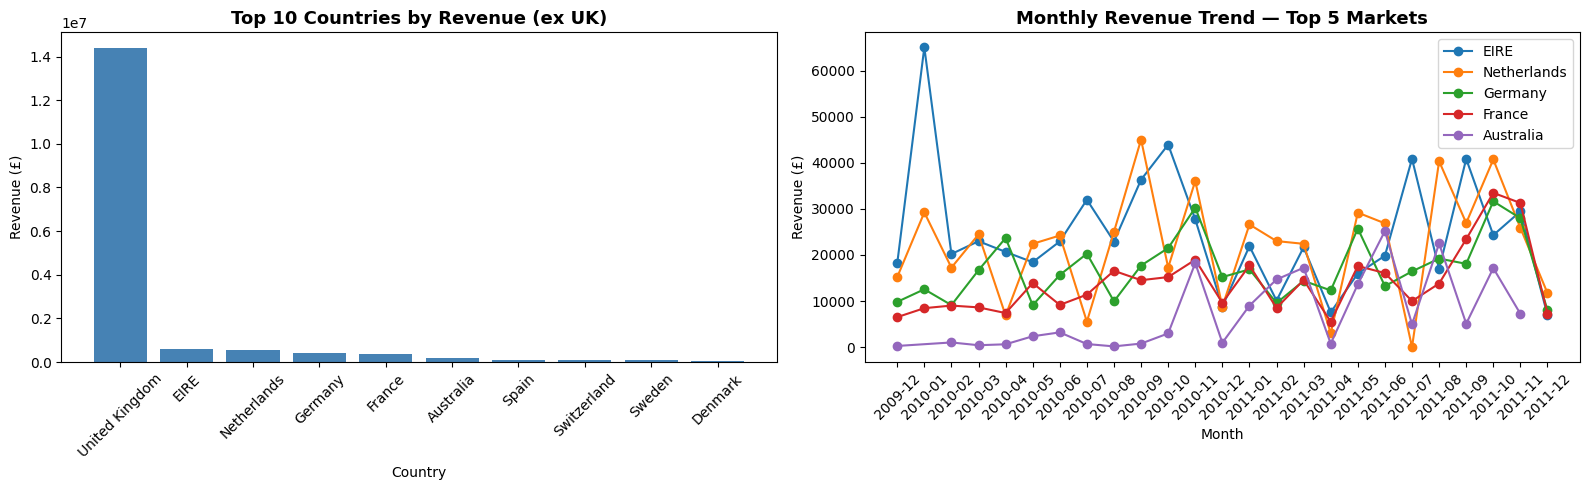

In [49]:
# Visualisation
country_pd = country_revenue.limit(10).toPandas()
trend_pd   = market_trend.toPandas()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.bar(country_pd["Country"], country_pd["total_revenue"], color="steelblue")
ax1.set_title("Top 10 Countries by Revenue (ex UK)", fontsize=13, fontweight="bold")
ax1.set_xlabel("Country")
ax1.set_ylabel("Revenue (£)")
ax1.tick_params(axis="x", rotation=45)

for country in top5_countries:
    subset = trend_pd[trend_pd["Country"] == country]
    ax2.plot(subset["YearMonth"], subset["monthly_revenue"], marker="o", label=country)
ax2.set_title("Monthly Revenue Trend — Top 5 Markets", fontsize=13, fontweight="bold")
ax2.set_xlabel("Month")
ax2.set_ylabel("Revenue (£)")
ax2.tick_params(axis="x", rotation=45)
ax2.legend()

plt.tight_layout()
plt.show()

In [50]:
test_df = retail_df.sample(0.01)
test_df.show()

+-------+---------+--------------------+--------+-------------------+-----+----------+--------------+
|Invoice|StockCode|         Description|Quantity|        InvoiceDate|Price|CustomerID|       Country|
+-------+---------+--------------------+--------+-------------------+-----+----------+--------------+
| 499057|   85099B|JUMBO BAG RED WHI...|       4|2010-02-24 13:48:00| 1.95|     15898|United Kingdom|
| 500030|    21257|VICTORIAN SEWING ...|       2|2010-03-04 11:29:00| 7.95|     14527|United Kingdom|
| 500843|    21984|PACK OF 12 PINK P...|       1|2010-03-10 12:13:00| 0.29|     17348|United Kingdom|
| 501479|    22064|PINK DOUGHNUT TRI...|      12|2010-03-17 09:43:00| 1.65|     16945|United Kingdom|
| 502847|    22557|PLASTERS IN TIN V...|       2|2010-03-28 13:47:00| 1.65|     14572|United Kingdom|
| 502854|   72801D|S/4 SKY BLUE DINN...|       1|2010-03-28 14:48:00| 1.25|     13684|United Kingdom|
| 503150|    21135|VICTORIAN  METAL ...|       8|2010-03-30 12:22:00| 1.69|     15

In [51]:
# Revenue by country excluding UK — DataFrame API
country_revenue = retail_df \
    .filter(col("Country") != "United Kingdom") \
    .groupBy("Country") \
    .agg(
        F.round(F.sum(F.col("Quantity") * F.col("Price")), 2).alias("total_revenue"),
        F.countDistinct("CustomerID").alias("unique_customers"),
        F.countDistinct("Invoice").alias("total_orders")
    ) \
    .orderBy(col("total_revenue").desc())

print("=== Revenue by Country (ex UK) ===")
country_revenue.show(15, truncate=False)

=== Revenue by Country (ex UK) ===
+---------------+-------------+----------------+------------+
|Country        |total_revenue|unique_customers|total_orders|
+---------------+-------------+----------------+------------+
|EIRE           |616570.54    |5               |567         |
|Netherlands    |554038.09    |22              |228         |
|Germany        |425019.71    |107             |789         |
|France         |348768.96    |95              |614         |
|Australia      |169283.46    |15              |95          |
|Spain          |108332.49    |41              |154         |
|Switzerland    |100061.94    |22              |90          |
|Sweden         |91515.82     |19              |104         |
|Denmark        |68580.69     |12              |43          |
|Belgium        |65387.82     |29              |149         |
|Norway         |56322.5      |13              |45          |
|Portugal       |55554.78     |24              |93          |
|Channel Islands|44623.33     |13  